# Data Exploration

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
import glob


sys.path.append(os.path.abspath("../scripts"))

from preprocess import load_data
from evaluate import evaluate_model
from plots import plot_degradation, plot_unique_frequencies, plot_nyquist

In [3]:
df = load_data("03-06-24", "A1.csv")
df.columns.values

array(['mode', 'ox/red', 'error', 'control changes', 'Ns changes',
       'counter inc.', 'Ns', 'I Range', 'time/s', 'control/V/mA',
       'Ecell/V', 'I/mA', 'dq/mA.h', '(Q-Qo)/mA.h', '|Energy|/W.h',
       'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'Q charge/discharge/mA.h',
       'half cycle', 'Energy charge/W.h', 'Energy discharge/W.h',
       'Capacitance charge/µF', 'Capacitance discharge/µF', 'step time/s',
       'z cycle', 'Re(Z)/Ohm', 'Im(Z)/Ohm', 'Re(Y)/Ohm-1', 'Im(Y)/Ohm-1',
       '|Y|/Ohm-1', 'Phase(Y)/deg', 'x', 'Q discharge/mA.h',
       'Q charge/mA.h', 'Capacity/mA.h', 'Efficiency/%', 'control/V',
       'control/mA', 'cycle number', 'P/W', 'R/Ohm'], dtype=object)

In [17]:
df_cycle = df[df['cycle number'] == 1].copy()

df_charge = df_cycle[df_cycle['I/mA'] > 0].copy() 
df_discharge = df_cycle[df_cycle['I/mA'] < 0].copy()     # DataFrame for discharging steps.

In [18]:
df_charge[['cycle number', 'I/mA']]

,cycle number,I/mA
340,1.0,7990.0
341,1.0,7990.0
342,1.0,8000.0
343,1.0,8000.0
344,1.0,8000.0
...,...,...
629,1.0,358.0
630,1.0,193.0
636,1.0,164.0
637,1.0,104.0


In [19]:
df_discharge[['cycle number', 'I/mA']]

,cycle number,I/mA
462,1.0,-353.0
463,1.0,-379.0
466,1.0,-693.0
467,1.0,-438.0
468,1.0,-645.0
...,...,...
631,1.0,-124.0
632,1.0,-295.0
633,1.0,-279.0
634,1.0,-95.6


## Preprocess for exploration

In [29]:
df = df[(df['freq/Hz'] > 0.2) & (df['freq/Hz'] <= 20000)]
unique_freqs = np.array(df['freq/Hz'].unique())
unique_freqs.sort()

print(unique_freqs)

[2.54e-01 3.40e-01 4.56e-01 6.12e-01 8.22e-01 9.99e-01 1.10e+00 1.33e+00
 1.48e+00 1.78e+00 1.99e+00 2.37e+00 2.66e+00 3.16e+00 3.57e+00 4.22e+00
 4.80e+00 5.62e+00 6.43e+00 7.50e+00 8.64e+00 1.00e+01 1.16e+01 1.33e+01
 1.55e+01 1.78e+01 2.09e+01 2.37e+01 2.80e+01 3.16e+01 3.75e+01 4.22e+01
 5.03e+01 5.62e+01 6.76e+01 7.50e+01 9.06e+01 1.02e+02 1.22e+02 1.35e+02
 1.63e+02 1.78e+02 2.19e+02 2.37e+02 2.94e+02 3.16e+02 3.94e+02 4.22e+02
 5.29e+02 5.64e+02 7.10e+02 7.50e+02 9.52e+02 1.00e+03 1.28e+03 1.33e+03
 1.71e+03 1.78e+03 2.30e+03 2.37e+03 3.09e+03 3.16e+03 4.14e+03 4.22e+03
 5.56e+03 5.62e+03 7.45e+03 7.50e+03 1.00e+04]


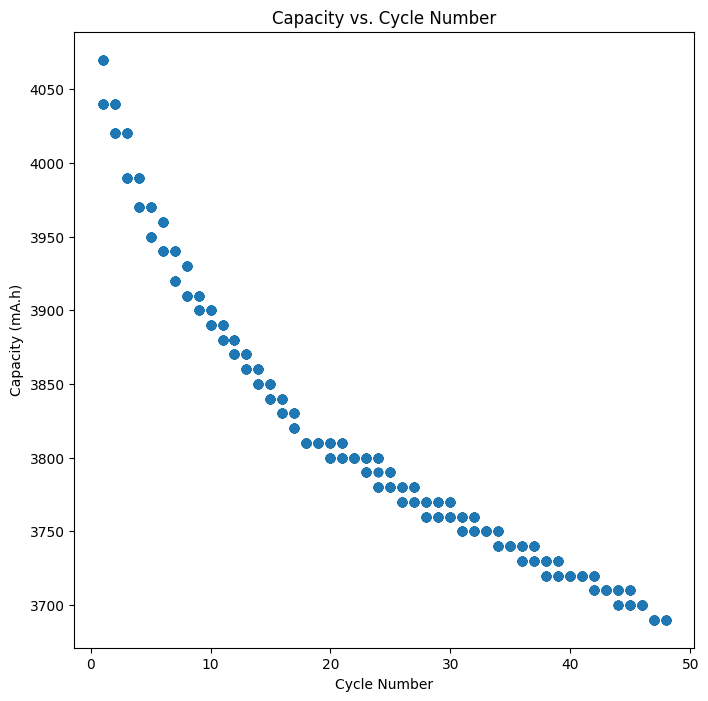

In [30]:
plot_degradation(df)

In [34]:
filtered_df=df[df['cycle number'] == 1]

In [11]:
unique_freqs_by_cycle = {}

all_cycles = sorted(df['cycle number'].unique())
for cycle in all_cycles:
    cycle_freqs = np.sort(df[df['cycle number'] == cycle]['freq/Hz'].unique())
    unique_freqs_by_cycle[cycle] = cycle_freqs
    print(f"Cycle {cycle} frequency points: {cycle_freqs}")

# Compute the intersection of frequency sets
common_freqs = set(unique_freqs_by_cycle[all_cycles[0]])
for cycle in all_cycles:
    common_freqs = common_freqs.intersection(set(unique_freqs_by_cycle[cycle]))

print("Common frequency points across all cycles:", np.sort(list(common_freqs)))


Cycle 1.0 frequency points: [2.54e-01 3.40e-01 4.56e-01 6.12e-01 8.22e-01 9.99e-01 1.10e+00 1.33e+00
 1.48e+00 1.78e+00 1.99e+00 2.37e+00 2.66e+00 3.16e+00 3.57e+00 4.22e+00
 4.80e+00 5.62e+00 6.43e+00 7.50e+00 8.64e+00 1.00e+01 1.16e+01 1.33e+01
 1.55e+01 1.78e+01 2.09e+01 2.37e+01 2.80e+01 3.16e+01 3.75e+01 4.22e+01
 5.03e+01 5.62e+01 6.76e+01 7.50e+01 9.06e+01 1.02e+02 1.22e+02 1.35e+02
 1.63e+02 1.78e+02 2.19e+02 2.37e+02 2.94e+02 3.16e+02 3.94e+02 4.22e+02
 5.29e+02 5.64e+02 7.10e+02 7.50e+02 9.52e+02 1.00e+03 1.28e+03 1.33e+03
 1.71e+03 1.78e+03 2.30e+03 2.37e+03 3.09e+03 3.16e+03 4.14e+03 4.22e+03
 5.56e+03 5.62e+03 7.45e+03 7.50e+03 1.00e+04]
Cycle 2.0 frequency points: [2.54e-01 3.40e-01 4.56e-01 6.12e-01 8.22e-01 9.99e-01 1.10e+00 1.33e+00
 1.48e+00 1.78e+00 1.99e+00 2.37e+00 2.66e+00 3.16e+00 3.57e+00 4.22e+00
 4.80e+00 5.62e+00 6.43e+00 7.50e+00 8.64e+00 1.00e+01 1.16e+01 1.33e+01
 1.55e+01 1.78e+01 2.09e+01 2.37e+01 2.80e+01 3.16e+01 3.75e+01 4.22e+01
 5.03e+01 5.62e+01 6.

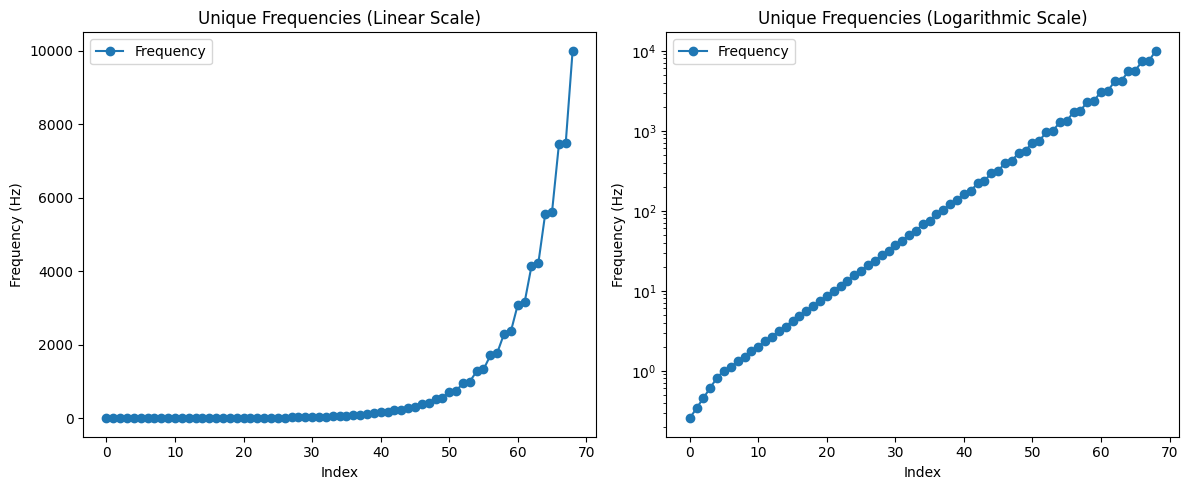

In [12]:
plot_unique_frequencies(unique_freqs)

In [19]:
unique_counts_by_cycle = {}

# Get a sorted list of unique cycle numbers.
all_cycles = sorted(df['cycle number'].unique())

# Loop through each cycle, count, and print the unique frequencies.
for cycle in all_cycles:
    # Filter the DataFrame for the current cycle and count unique frequencies
    unique_count = len(np.unique(df[df['cycle number'] == cycle]['freq/Hz']))
    unique_counts_by_cycle[cycle] = unique_count
    print(f"Cycle {cycle} has {unique_count} unique frequency points.")


Cycle 1.0 has 69 unique frequency points.
Cycle 2.0 has 69 unique frequency points.
Cycle 3.0 has 69 unique frequency points.
Cycle 4.0 has 69 unique frequency points.
Cycle 5.0 has 69 unique frequency points.
Cycle 6.0 has 69 unique frequency points.
Cycle 7.0 has 69 unique frequency points.
Cycle 8.0 has 69 unique frequency points.
Cycle 9.0 has 69 unique frequency points.
Cycle 10.0 has 69 unique frequency points.
Cycle 11.0 has 69 unique frequency points.
Cycle 12.0 has 69 unique frequency points.
Cycle 13.0 has 69 unique frequency points.
Cycle 14.0 has 69 unique frequency points.
Cycle 15.0 has 69 unique frequency points.
Cycle 16.0 has 69 unique frequency points.
Cycle 17.0 has 69 unique frequency points.
Cycle 18.0 has 69 unique frequency points.
Cycle 19.0 has 69 unique frequency points.
Cycle 20.0 has 69 unique frequency points.
Cycle 21.0 has 69 unique frequency points.
Cycle 22.0 has 69 unique frequency points.
Cycle 23.0 has 69 unique frequency points.
Cycle 24.0 has 69 un